In [1]:
!uv add kiwipiepy konlpy pandas matplotlib seaborn numpy

Resolved 284 packages in 35ms
Audited 259 packages in 1ms


🎯 형태소 분석기 성능 비교 프로그램
📊 분석 대상:
   🔍 Kiwi, OKT, Komoran, Kkma
📈 비교 항목:
   ⏱️  속도, 🚫 불용어 처리, 📚 표제어 처리
📁 데이터:
   🎣 피싱 대화 500개 + 💬 일반 대화 500개

📂 파일 경로 확인:
   피싱 데이터: C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\phishing_6000_final.csv
   일반 데이터: C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\normal_6000_final.csv
✅ 모든 파일이 확인되었습니다!
Kiwi 초기화 중...
KoNLPy 분석기들 초기화 중...
🚀 형태소 분석기 성능 비교 시작!
📋 분석 설정:
   🎯 대상 분석기: Kiwi, OKT, Komoran, Kkma
   📊 샘플 크기: 피싱 500개 + 일반 500개 = 총 1000개
   🔍 비교 항목: 속도, 불용어 처리, 표제어 처리
📁 데이터 로드 중... (각 500개씩)
--------------------------------------------------
🔍 피싱 대화 데이터 로드: C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\phishing_6000_final.csv
   전체 피싱 데이터: 6000개
   샘플링된 피싱 데이터: 500개
🔍 일반 대화 데이터 로드: C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\normal_6000_final.csv
   전체 일반 데이터: 6000개
   샘플링된 일반 데이터: 500개
--------------------------------------------------
✅ 데이터 로드 완료!
   📊 분석 대상: 피싱 500개 + 일반 500개 = 총 1000개

📝 데이터 미리보기:

AttributeError: 'Axes' object has no attribute 'set_theta_offset'

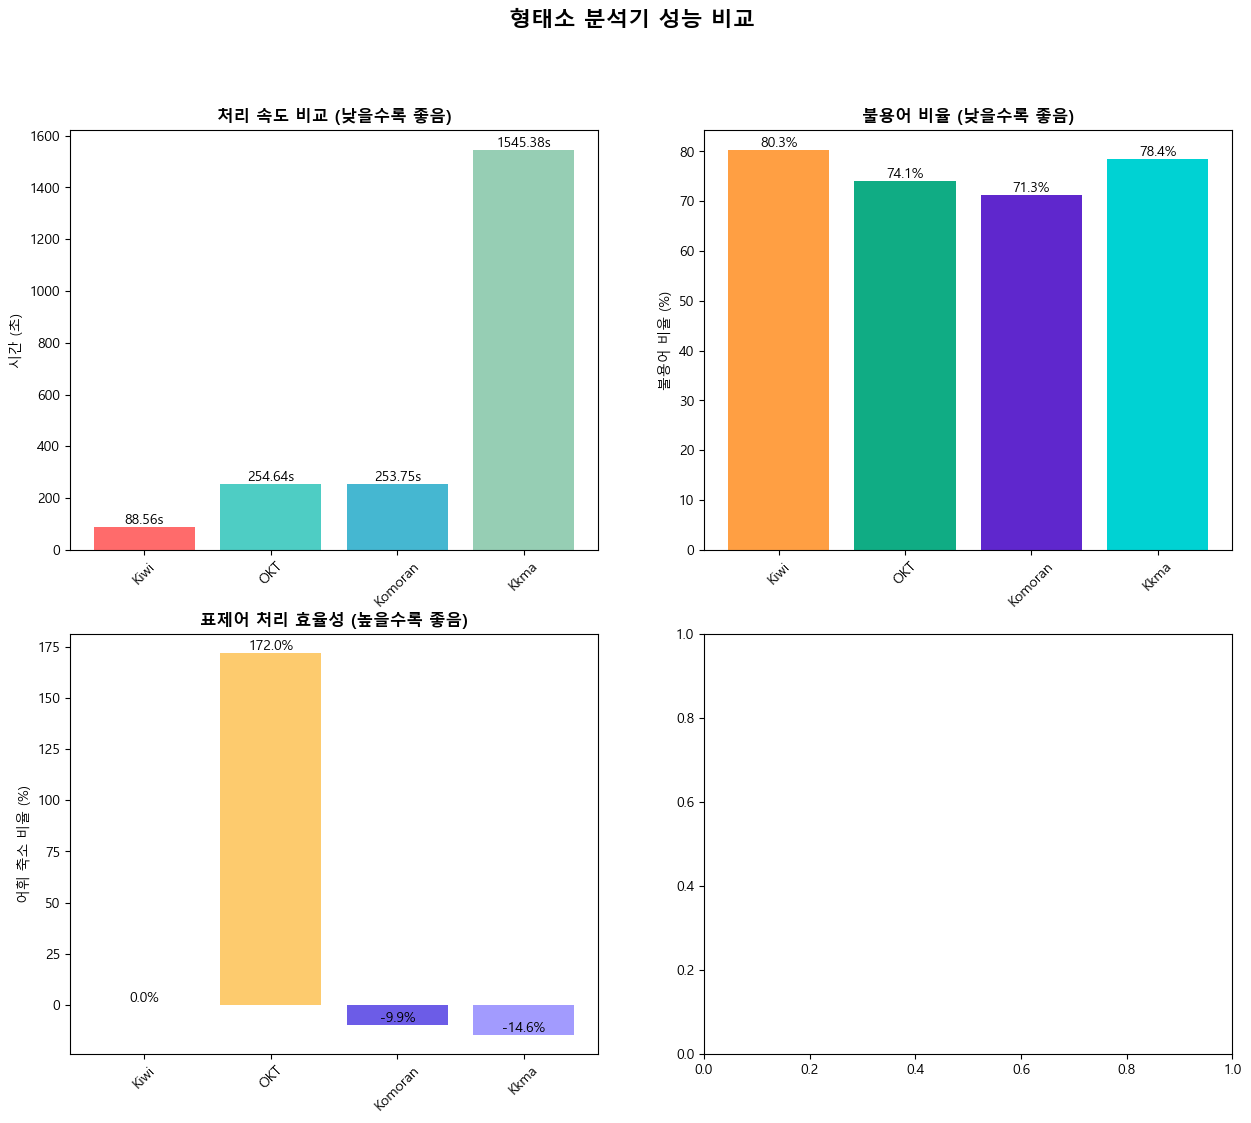

In [3]:
"""
형태소 분석기 4종 (Kiwi, OKT, Komoran, Kkma) 성능 비교
비교 항목: 속도, 불용어 처리, 표제어 처리
"""

import pandas as pd
import time
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# 형태소 분석기 import
try:
    from kiwipiepy import Kiwi
    KIWI_AVAILABLE = True
except ImportError:
    print("Kiwi 설치 필요: pip install kiwipiepy")
    KIWI_AVAILABLE = False

try:
    from konlpy.tag import Okt, Komoran, Kkma
    KONLPY_AVAILABLE = True
except ImportError:
    print("KoNLPy 설치 필요: pip install konlpy")
    KONLPY_AVAILABLE = False

# 한글 폰트 설정 (그래프용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

class MorphemeAnalyzerComparison:
    def __init__(self):
        """형태소 분석기 초기화"""
        self.analyzers = {}
        self.results = {
            'speed': {},
            'stopwords': {},
            'lemmatization': {}
        }
        
        # 분석기 초기화
        if KIWI_AVAILABLE:
            print("Kiwi 초기화 중...")
            self.analyzers['Kiwi'] = Kiwi()
        
        if KONLPY_AVAILABLE:
            print("KoNLPy 분석기들 초기화 중...")
            self.analyzers['OKT'] = Okt()
            self.analyzers['Komoran'] = Komoran()
            self.analyzers['Kkma'] = Kkma()
        
        # 불용어 리스트 (한국어 일반적인 불용어)
        self.stopwords = {
            '은', '는', '이', '가', '을', '를', '에', '에서', '로', '으로', 
            '와', '과', '의', '도', '만', '까지', '부터', '이다', '있다', '없다',
            '하다', '되다', '이것', '그것', '저것', '여기', '거기', '저기',
            '이곳', '그곳', '저곳', '나', '너', '우리', '그들', '것', '수', '때',
            '년', '월', '일', '시간', '분', '초', '그래서', '그러나', '하지만'
        }
    
    def load_data(self, phishing_path: str, normal_path: str, sample_size: int = 500) -> Tuple[List[str], List[str]]:
        """데이터 로드 및 샘플링"""
        print(f"📁 데이터 로드 중... (각 {sample_size}개씩)")
        print("-" * 50)
        
        try:
            # 피싱 데이터 로드
            print(f"🔍 피싱 대화 데이터 로드: {phishing_path}")
            phishing_df = pd.read_csv(phishing_path, encoding='utf-8')
            print(f"   전체 피싱 데이터: {len(phishing_df)}개")
            phishing_texts = phishing_df['text'].head(sample_size).tolist()
            print(f"   샘플링된 피싱 데이터: {len(phishing_texts)}개")
            
            # 일반 대화 데이터 로드
            print(f"🔍 일반 대화 데이터 로드: {normal_path}")
            normal_df = pd.read_csv(normal_path, encoding='utf-8')
            print(f"   전체 일반 데이터: {len(normal_df)}개")
            normal_texts = normal_df['text'].head(sample_size).tolist()
            print(f"   샘플링된 일반 데이터: {len(normal_texts)}개")
            
            print("-" * 50)
            print(f"✅ 데이터 로드 완료!")
            print(f"   📊 분석 대상: 피싱 {len(phishing_texts)}개 + 일반 {len(normal_texts)}개 = 총 {len(phishing_texts) + len(normal_texts)}개")
            
            # 샘플 텍스트 미리보기
            print(f"\n📝 데이터 미리보기:")
            print(f"   피싱 샘플: {phishing_texts[0][:500]}...")
            print(f"   일반 샘플: {normal_texts[0][:500]}...")
            
            return phishing_texts, normal_texts
            
        except FileNotFoundError as e:
            print(f"❌ 파일을 찾을 수 없습니다: {e}")
            raise
        except Exception as e:
            print(f"❌ 데이터 로드 중 오류 발생: {e}")
            raise
    
    def analyze_with_kiwi(self, text: str) -> Dict:
        """Kiwi 분석"""
        tokens = self.analyzers['Kiwi'].tokenize(text)
        
        # 형태소와 품사 분리
        morphemes = [(token.form, token.tag) for token in tokens]
        nouns = [token.form for token in tokens if token.tag.startswith('N')]
        
        # 표제어 처리 (동사, 형용사의 기본형)
        lemmas = []
        for token in tokens:
            if token.tag.startswith('V') or token.tag.startswith('A'):
                # Kiwi에서는 기본형이 따로 제공되지 않으므로 원형을 사용
                lemmas.append(token.form)
            else:
                lemmas.append(token.form)
        
        return {
            'morphemes': morphemes,
            'nouns': nouns,
            'lemmas': lemmas,
            'total_tokens': len(tokens)
        }
    
    def analyze_with_okt(self, text: str) -> Dict:
        """OKT 분석"""
        morphemes = self.analyzers['OKT'].pos(text)
        nouns = self.analyzers['OKT'].nouns(text)
        
        # 표제어 처리 (stem=True 옵션 사용)
        lemmas = [word for word, pos in self.analyzers['OKT'].pos(text, stem=True)]
        
        return {
            'morphemes': morphemes,
            'nouns': nouns,
            'lemmas': lemmas,
            'total_tokens': len(morphemes)
        }
    
    def analyze_with_komoran(self, text: str) -> Dict:
        """Komoran 분석"""
        morphemes = self.analyzers['Komoran'].pos(text)
        nouns = self.analyzers['Komoran'].nouns(text)
        
        # 표제어 처리 (기본형 추출)
        lemmas = []
        for word, pos in morphemes:
            if pos.startswith('V') or pos.startswith('A'):
                # 어간 추출 시도
                if word.endswith(('다', '는', '은', '를', '을')):
                    lemmas.append(word[:-1] + '다')
                else:
                    lemmas.append(word + '다' if not word.endswith('다') else word)
            else:
                lemmas.append(word)
        
        return {
            'morphemes': morphemes,
            'nouns': nouns,
            'lemmas': lemmas,
            'total_tokens': len(morphemes)
        }
    
    def analyze_with_kkma(self, text: str) -> Dict:
        """Kkma 분석"""
        morphemes = self.analyzers['Kkma'].pos(text)
        nouns = self.analyzers['Kkma'].nouns(text)
        
        # 표제어 처리
        lemmas = []
        for word, pos in morphemes:
            if pos.startswith('V') or pos.startswith('A'):
                # 기본형으로 변환
                if not word.endswith('다'):
                    lemmas.append(word + '다')
                else:
                    lemmas.append(word)
            else:
                lemmas.append(word)
        
        return {
            'morphemes': morphemes,
            'nouns': nouns,
            'lemmas': lemmas,
            'total_tokens': len(morphemes)
        }
    
    def measure_speed(self, texts: List[str]) -> Dict[str, float]:
        """속도 측정"""
        print("\n⏱️  속도 측정 시작...")
        print("=" * 60)
        speed_results = {}
        total_texts = len(texts)
        
        for name, analyzer in self.analyzers.items():
            print(f"\n🚀 {name} 속도 측정 중...")
            print(f"   📊 처리할 텍스트: {total_texts}개")
            
            start_time = time.time()
            processed = 0
            errors = 0
            
            for i, text in enumerate(texts):
                try:
                    if name == 'Kiwi':
                        self.analyze_with_kiwi(text)
                    elif name == 'OKT':
                        self.analyze_with_okt(text)
                    elif name == 'Komoran':
                        self.analyze_with_komoran(text)
                    elif name == 'Kkma':
                        self.analyze_with_kkma(text)
                    
                    processed += 1
                    
                    # 진행률 표시 (10%씩)
                    if (i + 1) % (total_texts // 10) == 0:
                        progress = ((i + 1) / total_texts) * 500
                        elapsed = time.time() - start_time
                        speed = (i + 1) / elapsed if elapsed > 0 else 0
                        print(f"   ⏳ 진행률: {progress:5.1f}% | 처리 속도: {speed:5.1f} 텍스트/초 | 경과: {elapsed:5.1f}초")
                        
                except Exception as e:
                    errors += 1
                    if errors <= 3:  # 처음 3개 오류만 출력
                        print(f"   ⚠️  텍스트 {i+1} 분석 오류: {str(e)[:50]}...")
                    continue
            
            end_time = time.time()
            total_time = end_time - start_time
            speed_results[name] = total_time
            
            print(f"   ✅ {name} 완료!")
            print(f"   📈 총 시간: {total_time:.2f}초")
            print(f"   📊 처리 완료: {processed}/{total_texts}개")
            print(f"   🔄 평균 속도: {processed/total_time:.1f} 텍스트/초")
            if errors > 0:
                print(f"   ⚠️  오류 발생: {errors}개")
        
        return speed_results
    
    def evaluate_stopwords_removal(self, texts: List[str]) -> Dict[str, float]:
        """불용어 처리 평가"""
        print("\n🚫 불용어 처리 성능 측정 시작...")
        print("=" * 60)
        stopword_results = {}
        sample_size = min(20, len(texts))  # 최대 20개 샘플로 테스트
        sample_texts = texts[:sample_size]
        
        print(f"📝 샘플 크기: {sample_size}개 텍스트")
        print(f"🚫 불용어 사전 크기: {len(self.stopwords)}개")
        
        for name, analyzer in self.analyzers.items():
            print(f"\n🔍 {name} 불용어 처리 평가 중...")
            total_tokens = 0
            stopwords_found = 0
            processed = 0
            
            for i, text in enumerate(sample_texts):
                try:
                    if name == 'Kiwi':
                        result = self.analyze_with_kiwi(text)
                    elif name == 'OKT':
                        result = self.analyze_with_okt(text)
                    elif name == 'Komoran':
                        result = self.analyze_with_komoran(text)
                    elif name == 'Kkma':
                        result = self.analyze_with_kkma(text)
                    
                    # 불용어 비율 계산
                    morphemes = [word for word, pos in result['morphemes']]
                    total_tokens += len(morphemes)
                    current_stopwords = sum(1 for word in morphemes if word in self.stopwords)
                    stopwords_found += current_stopwords
                    processed += 1
                    
                    # 진행률 표시
                    if (i + 1) % 5 == 0 or (i + 1) == sample_size:
                        progress = ((i + 1) / sample_size) * 500
                        current_ratio = stopwords_found / total_tokens if total_tokens > 0 else 0
                        print(f"   ⏳ 진행률: {progress:5.1f}% | 현재 불용어 비율: {current_ratio*500:5.1f}%")
                    
                except Exception as e:
                    print(f"   ⚠️  텍스트 {i+1} 분석 오류: {str(e)[:50]}...")
                    continue
            
            # 불용어 제거 효율성 (낮을수록 좋음 - 불용어가 적게 남아있음)
            stopword_ratio = stopwords_found / total_tokens if total_tokens > 0 else 0
            stopword_results[name] = stopword_ratio
            
            print(f"   ✅ {name} 완료!")
            print(f"   📊 처리된 텍스트: {processed}/{sample_size}개")
            print(f"   📈 총 토큰: {total_tokens}개")
            print(f"   🚫 발견된 불용어: {stopwords_found}개")
            print(f"   📉 불용어 비율: {stopword_ratio*500:.1f}%")
        
        return stopword_results
    
    def evaluate_lemmatization(self, texts: List[str]) -> Dict[str, float]:
        """표제어 처리 평가"""
        print("\n📚 표제어 처리 성능 측정 시작...")
        print("=" * 60)
        lemma_results = {}
        sample_size = min(20, len(texts))  # 최대 20개 샘플로 테스트
        sample_texts = texts[:sample_size]
        
        print(f"📝 샘플 크기: {sample_size}개 텍스트")
        
        for name, analyzer in self.analyzers.items():
            print(f"\n📖 {name} 표제어 처리 평가 중...")
            original_words = []
            lemmatized_words = []
            processed = 0
            
            for i, text in enumerate(sample_texts):
                try:
                    if name == 'Kiwi':
                        result = self.analyze_with_kiwi(text)
                    elif name == 'OKT':
                        result = self.analyze_with_okt(text)
                    elif name == 'Komoran':
                        result = self.analyze_with_komoran(text)
                    elif name == 'Kkma':
                        result = self.analyze_with_kkma(text)
                    
                    # 원본 단어와 표제어 비교
                    morphemes = [word for word, pos in result['morphemes']]
                    lemmas = result['lemmas']
                    
                    original_words.extend(morphemes)
                    lemmatized_words.extend(lemmas)
                    processed += 1
                    
                    # 진행률 표시
                    if (i + 1) % 5 == 0 or (i + 1) == sample_size:
                        progress = ((i + 1) / sample_size) * 500
                        current_original = len(set(original_words))
                        current_lemma = len(set(lemmatized_words))
                        current_reduction = (current_original - current_lemma) / current_original if current_original > 0 else 0
                        print(f"   ⏳ 진행률: {progress:5.1f}% | 현재 축소율: {current_reduction*500:5.1f}%")
                    
                except Exception as e:
                    print(f"   ⚠️  텍스트 {i+1} 분석 오류: {str(e)[:50]}...")
                    continue
            
            # 표제어 처리 효율성 (중복 제거 비율)
            original_unique = len(set(original_words))
            lemma_unique = len(set(lemmatized_words))
            
            # 표제어화로 인한 어휘 축소 비율
            reduction_ratio = (original_unique - lemma_unique) / original_unique if original_unique > 0 else 0
            lemma_results[name] = reduction_ratio
            
            print(f"   ✅ {name} 완료!")
            print(f"   📊 처리된 텍스트: {processed}/{sample_size}개")
            print(f"   📈 원본 고유 단어: {original_unique}개")
            print(f"   📉 표제어 고유 단어: {lemma_unique}개")
            print(f"   🎯 어휘 축소율: {reduction_ratio*500:.1f}%")
        
        return lemma_results
    
    def run_comparison(self, phishing_path: str, normal_path: str, sample_size: int = 500):
        """전체 비교 실행"""
        print("🚀 형태소 분석기 성능 비교 시작!")
        print("=" * 80)
        print(f"📋 분석 설정:")
        print(f"   🎯 대상 분석기: {', '.join(self.analyzers.keys())}")
        print(f"   📊 샘플 크기: 피싱 {sample_size}개 + 일반 {sample_size}개 = 총 {sample_size*2}개")
        print(f"   🔍 비교 항목: 속도, 불용어 처리, 표제어 처리")
        print("=" * 80)
        
        # 데이터 로드
        phishing_texts, normal_texts = self.load_data(phishing_path, normal_path, sample_size)
        all_texts = phishing_texts + normal_texts
        
        print(f"\n🎉 총 {len(all_texts)}개 텍스트로 분석 시작!")
        print(f"   📁 피싱 대화: {len(phishing_texts)}개")
        print(f"   📁 일반 대화: {len(normal_texts)}개")
        
        # 1. 속도 측정
        print("\n" + "🏃‍♂️ " + "="*20 + " 1단계: 속도 측정 " + "="*20)
        speed_results = self.measure_speed(all_texts)
        self.results['speed'] = speed_results
        
        # 2. 불용어 처리 평가
        print("\n" + "🚫 " + "="*18 + " 2단계: 불용어 처리 평가 " + "="*18)
        stopword_results = self.evaluate_stopwords_removal(all_texts)
        self.results['stopwords'] = stopword_results
        
        # 3. 표제어 처리 평가
        print("\n" + "📚 " + "="*18 + " 3단계: 표제어 처리 평가 " + "="*18)
        lemma_results = self.evaluate_lemmatization(all_texts)
        self.results['lemmatization'] = lemma_results
        
        # 결과 출력
        print("\n" + "📊 " + "="*20 + " 최종 결과 " + "="*20)
        self.print_results()
        
        # 시각화
        print("\n📈 결과 시각화 중...")
        self.visualize_results()
        
        print("\n🎉 모든 분석이 완료되었습니다!")
        print("📊 그래프 창에서 상세 결과를 확인하세요.")
        
        return self.results
    
    def print_results(self):
        """결과 출력"""
        print("\n" + "="*60)
        print("              형태소 분석기 성능 비교 결과")
        print("="*60)
        
        # 속도 결과
        print("\n1. 속도 측정 결과 (초, 낮을수록 좋음)")
        print("-" * 40)
        speed_sorted = sorted(self.results['speed'].items(), key=lambda x: x[1])
        for i, (name, time_taken) in enumerate(speed_sorted, 1):
            print(f"{i}위. {name:10s}: {time_taken:8.2f}초")
        
        # 불용어 처리 결과
        print("\n2. 불용어 처리 결과 (불용어 비율, 낮을수록 좋음)")
        print("-" * 40)
        stopword_sorted = sorted(self.results['stopwords'].items(), key=lambda x: x[1])
        for i, (name, ratio) in enumerate(stopword_sorted, 1):
            print(f"{i}위. {name:10s}: {ratio:8.3f} ({ratio*500:.1f}%)")
        
        # 표제어 처리 결과
        print("\n3. 표제어 처리 결과 (어휘 축소 비율, 높을수록 좋음)")
        print("-" * 40)
        lemma_sorted = sorted(self.results['lemmatization'].items(), key=lambda x: x[1], reverse=True)
        for i, (name, ratio) in enumerate(lemma_sorted, 1):
            print(f"{i}위. {name:10s}: {ratio:8.3f} ({ratio*500:.1f}%)")
        
        # 종합 순위
        print("\n4. 종합 평가")
        print("-" * 40)
        self.calculate_overall_ranking()
    
    def calculate_overall_ranking(self):
        """종합 순위 계산"""
        rankings = {}
        
        # 각 항목별 순위 계산
        speed_rank = {name: i+1 for i, (name, _) in enumerate(sorted(self.results['speed'].items(), key=lambda x: x[1]))}
        stopword_rank = {name: i+1 for i, (name, _) in enumerate(sorted(self.results['stopwords'].items(), key=lambda x: x[1]))}
        lemma_rank = {name: i+1 for i, (name, _) in enumerate(sorted(self.results['lemmatization'].items(), key=lambda x: x[1], reverse=True))}
        
        # 종합 점수 계산 (순위 합계, 낮을수록 좋음)
        for name in self.analyzers.keys():
            total_rank = speed_rank.get(name, 5) + stopword_rank.get(name, 5) + lemma_rank.get(name, 5)
            rankings[name] = total_rank
        
        # 종합 순위 출력
        overall_sorted = sorted(rankings.items(), key=lambda x: x[1])
        for i, (name, total_rank) in enumerate(overall_sorted, 1):
            print(f"{i}위. {name:10s}: 점수 {total_rank:2d}점 (속도:{speed_rank.get(name, '-')}위, 불용어:{stopword_rank.get(name, '-')}위, 표제어:{lemma_rank.get(name, '-')}위)")
    
    def visualize_results(self):
        """결과 시각화"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('형태소 분석기 성능 비교', fontsize=16, fontweight='bold')
        
        # 1. 속도 비교
        if self.results['speed']:
            names = list(self.results['speed'].keys())
            speeds = list(self.results['speed'].values())
            
            ax1 = axes[0, 0]
            bars1 = ax1.bar(names, speeds, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
            ax1.set_title('처리 속도 비교 (낮을수록 좋음)', fontweight='bold')
            ax1.set_ylabel('시간 (초)')
            ax1.tick_params(axis='x', rotation=45)
            
            # 값 표시
            for bar, speed in zip(bars1, speeds):
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height,
                        f'{speed:.2f}s', ha='center', va='bottom')
        
        # 2. 불용어 처리 비교
        if self.results['stopwords']:
            names = list(self.results['stopwords'].keys())
            stopwords = [ratio * 500 for ratio in self.results['stopwords'].values()]
            
            ax2 = axes[0, 1]
            bars2 = ax2.bar(names, stopwords, color=['#FF9F43', '#10AC84', '#5F27CD', '#00D2D3'])
            ax2.set_title('불용어 비율 (낮을수록 좋음)', fontweight='bold')
            ax2.set_ylabel('불용어 비율 (%)')
            ax2.tick_params(axis='x', rotation=45)
            
            # 값 표시
            for bar, ratio in zip(bars2, stopwords):
                height = bar.get_height()
                ax2.text(bar.get_x() + bar.get_width()/2., height,
                        f'{ratio:.1f}%', ha='center', va='bottom')
        
        # 3. 표제어 처리 비교
        if self.results['lemmatization']:
            names = list(self.results['lemmatization'].keys())
            lemmas = [ratio * 500 for ratio in self.results['lemmatization'].values()]
            
            ax3 = axes[1, 0]
            bars3 = ax3.bar(names, lemmas, color=['#FD79A8', '#FDCB6E', '#6C5CE7', '#A29BFE'])
            ax3.set_title('표제어 처리 효율성 (높을수록 좋음)', fontweight='bold')
            ax3.set_ylabel('어휘 축소 비율 (%)')
            ax3.tick_params(axis='x', rotation=45)
            
            # 값 표시
            for bar, ratio in zip(bars3, lemmas):
                height = bar.get_height()
                ax3.text(bar.get_x() + bar.get_width()/2., height,
                        f'{ratio:.1f}%', ha='center', va='bottom')
        
        # 4. 종합 레이더 차트
        ax4 = axes[1, 1]
        if len(self.analyzers) > 0:
            self.create_radar_chart(ax4)
        
        plt.tight_layout()
        plt.show()
    
    def create_radar_chart(self, ax):
        """레이더 차트 생성"""
        from math import pi
        
        # 데이터 정규화 (0-1 범위, 높을수록 좋게)
        categories = ['속도', '불용어처리', '표제어처리']
        
        analyzers_data = {}
        for name in self.analyzers.keys():
            # 속도는 역수 정규화 (빠를수록 좋음)
            speed_score = 1 / (self.results['speed'].get(name, 1) + 1)
            # 불용어는 1에서 비율을 뺀 값 (적을수록 좋음)
            stopword_score = 1 - self.results['stopwords'].get(name, 0)
            # 표제어는 그대로 사용 (높을수록 좋음)
            lemma_score = self.results['lemmatization'].get(name, 0)
            
            analyzers_data[name] = [speed_score, stopword_score, lemma_score]
        
        # 각도 계산
        angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
        angles += angles[:1]  # 닫힌 도형을 위해
        
        ax.set_theta_offset(pi / 2)
        ax.set_theta_direction(-1)
        ax.set_thetagrids([angle * 180 / pi for angle in angles[:-1]], categories)
        
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
        for i, (name, values) in enumerate(analyzers_data.items()):
            values += values[:1]  # 닫힌 도형을 위해
            ax.plot(angles, values, 'o-', linewidth=2, label=name, color=colors[i % len(colors)])
            ax.fill(angles, values, alpha=0.25, color=colors[i % len(colors)])
        
        ax.set_ylim(0, 1)
        ax.set_title('종합 성능 비교 (바깥쪽이 좋음)', fontweight='bold', pad=20)
        ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))


def main():
    """메인 실행 함수"""
    print("🎯 형태소 분석기 성능 비교 프로그램")
    print("=" * 50)
    print("📊 분석 대상:")
    print("   🔍 Kiwi, OKT, Komoran, Kkma")
    print("📈 비교 항목:")  
    print("   ⏱️  속도, 🚫 불용어 처리, 📚 표제어 처리")
    print("📁 데이터:")
    print("   🎣 피싱 대화 500개 + 💬 일반 대화 500개")
    print("=" * 50)
    
    # 파일 경로 설정
    phishing_path = r"C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\phishing_6000_final.csv"
    normal_path = r"C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\normal_6000_final.csv"
    
    print(f"\n📂 파일 경로 확인:")
    print(f"   피싱 데이터: {phishing_path}")
    print(f"   일반 데이터: {normal_path}")
    
    # 파일 존재 확인
    import os
    if not os.path.exists(phishing_path):
        print(f"❌ 피싱 데이터 파일을 찾을 수 없습니다: {phishing_path}")
        return
    if not os.path.exists(normal_path):
        print(f"❌ 일반 데이터 파일을 찾을 수 없습니다: {normal_path}")
        return
    
    print("✅ 모든 파일이 확인되었습니다!")
    
    try:
        # 비교 실행
        comparison = MorphemeAnalyzerComparison()
        results = comparison.run_comparison(phishing_path, normal_path, sample_size=500)
        
        print(f"\n🏆 최종 요약:")
        print(f"   ⚡ 가장 빠른 분석기: {min(results['speed'].items(), key=lambda x: x[1])[0]}")
        print(f"   🚫 불용어 처리 최고: {min(results['stopwords'].items(), key=lambda x: x[1])[0]}")
        print(f"   📚 표제어 처리 최고: {max(results['lemmatization'].items(), key=lambda x: x[1])[0]}")
        
    except Exception as e:
        print(f"❌ 오류 발생: {e}")
        print("💡 가능한 해결책:")
        print("   1. 필요한 라이브러리 설치: pip install kiwipiepy konlpy pandas matplotlib seaborn")
        print("   2. 파일 경로 확인")
        print("   3. CSV 파일 형식 확인")
        raise


if __name__ == "__main__":
    main()

🎯 형태소 분석기 성능 비교 프로그램
📊 분석 대상:
   🔍 Kiwi, OKT, Komoran, Kkma
📈 비교 항목:
   ⏱️  속도, 🚫 불용어 처리, 🎯 품사 태깅 정확도, 🔍 미등록 단어 처리
📁 데이터:
   🎣 피싱 대화 500개 + 💬 일반 대화 500개

📂 파일 경로 확인:
   피싱 데이터: C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\phishing_6000_final.csv
   일반 데이터: C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\normal_6000_final.csv
✅ 모든 파일이 확인되었습니다!
Kiwi 초기화 중...
KoNLPy 분석기들 초기화 중...
🚀 형태소 분석기 성능 비교 시작!
📋 분석 설정:
   🎯 대상 분석기: Kiwi, OKT, Komoran, Kkma
   📊 샘플 크기: 피싱 500개 + 일반 500개 = 총 1000개
   🔍 비교 항목: 속도, 불용어 처리, 품사 태깅 정확도, 미등록 단어 처리
📁 데이터 로드 중... (각 500개씩)
--------------------------------------------------
🔍 피싱 대화 데이터 로드: C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\phishing_6000_final.csv
   전체 피싱 데이터: 6000개
   샘플링된 피싱 데이터: 500개
🔍 일반 대화 데이터 로드: C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\normal_6000_final.csv
   전체 일반 데이터: 6000개
   샘플링된 일반 데이터: 500개
--------------------------------------------------
✅ 데이터 로드 완료!
   📊 분석 대상: 피싱 500개 + 

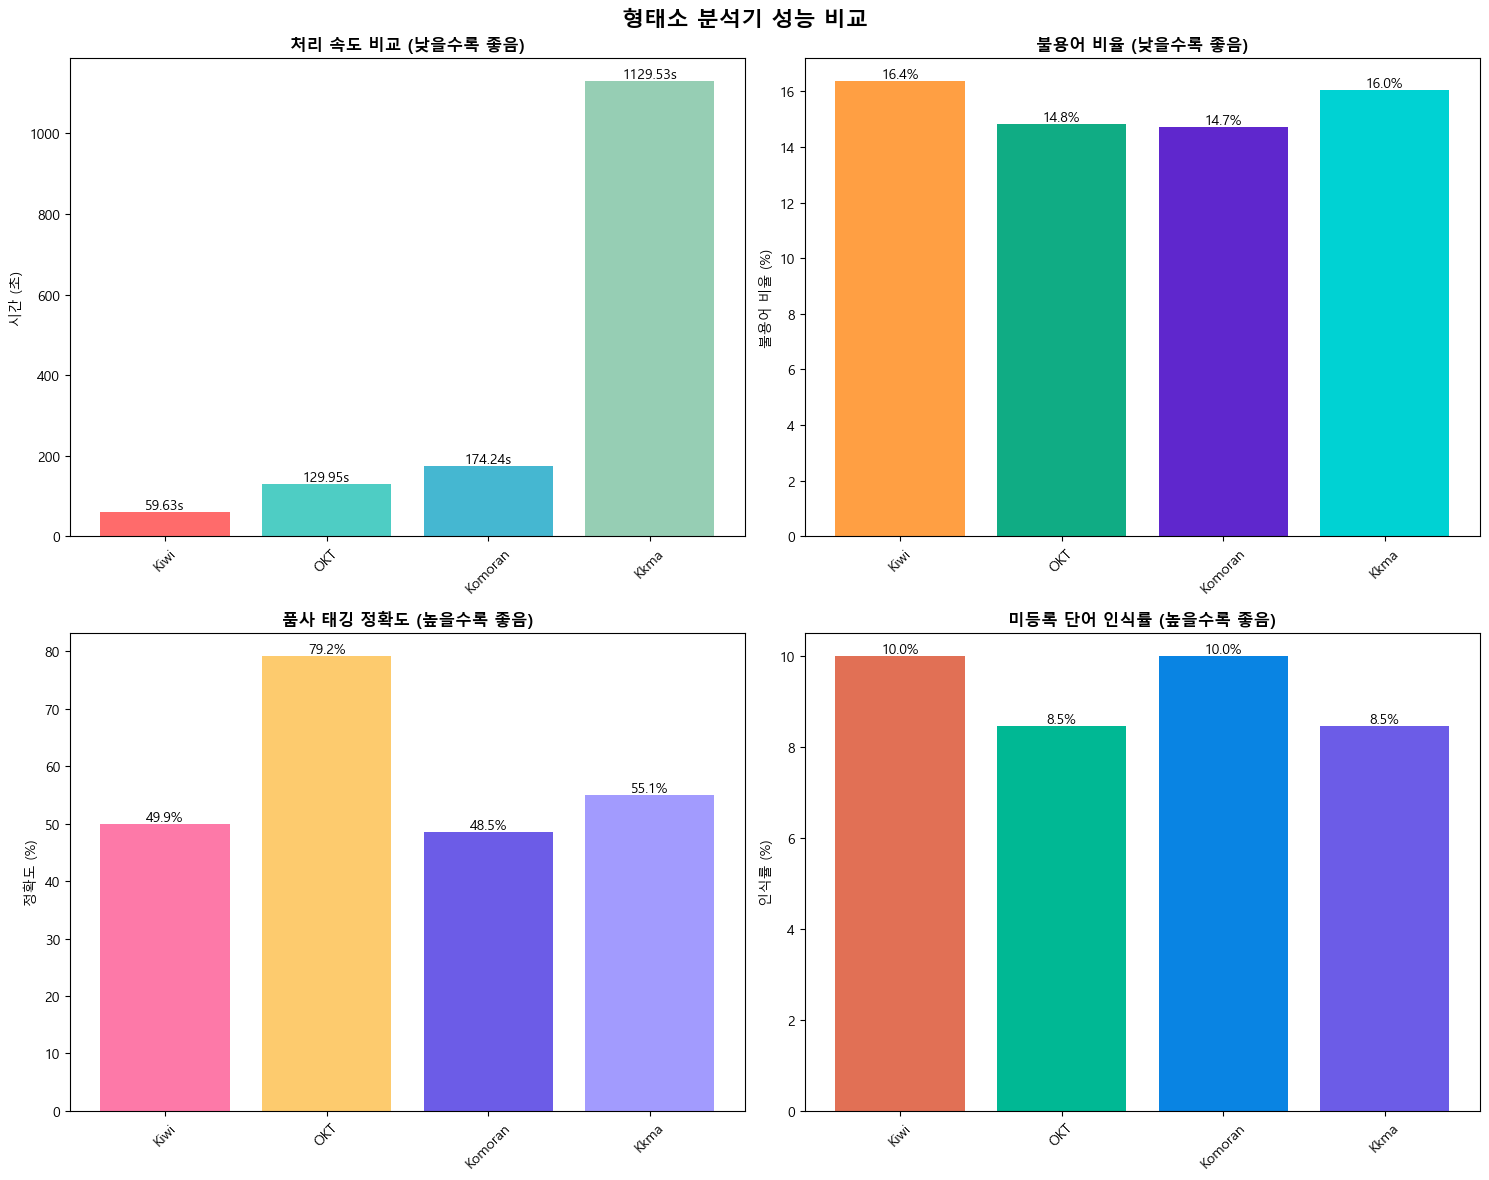


🎉 모든 분석이 완료되었습니다!
📊 그래프 창에서 상세 결과를 확인하세요.

🏆 최종 요약:
   ⚡ 가장 빠른 분석기: Kiwi
   🚫 불용어 처리 최고: Komoran
   🎯 품사 정확도 최고: OKT
   🔍 미등록 단어 처리 최고: Kiwi


In [4]:
"""
형태소 분석기 4종 (Kiwi, OKT, Komoran, Kkma) 성능 비교
비교 항목: 속도, 불용어 처리, 품사 태깅 정확도, 미등록 단어 처리 능력
"""

import pandas as pd
import time
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# 형태소 분석기 import
try:
    from kiwipiepy import Kiwi
    KIWI_AVAILABLE = True
except ImportError:
    print("Kiwi 설치 필요: pip install kiwipiepy")
    KIWI_AVAILABLE = False

try:
    from konlpy.tag import Okt, Komoran, Kkma
    KONLPY_AVAILABLE = True
except ImportError:
    print("KoNLPy 설치 필요: pip install konlpy")
    KONLPY_AVAILABLE = False

# 한글 폰트 설정 (그래프용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

class MorphemeAnalyzerComparison:
    def __init__(self):
        """형태소 분석기 초기화"""
        self.analyzers = {}
        self.results = {
            'speed': {},
            'stopwords': {},
            'pos_accuracy': {},
            'unknown_words': {}
        }
        
        # 분석기 초기화
        if KIWI_AVAILABLE:
            print("Kiwi 초기화 중...")
            self.analyzers['Kiwi'] = Kiwi()
        
        if KONLPY_AVAILABLE:
            print("KoNLPy 분석기들 초기화 중...")
            self.analyzers['OKT'] = Okt()
            self.analyzers['Komoran'] = Komoran()
            self.analyzers['Kkma'] = Kkma()
        
        # 불용어 리스트 (한국어 일반적인 불용어)
        self.stopwords = {
            '은', '는', '이', '가', '을', '를', '에', '에서', '로', '으로', 
            '와', '과', '의', '도', '만', '까지', '부터', '이다', '있다', '없다',
            '하다', '되다', '이것', '그것', '저것', '여기', '거기', '저기',
            '이곳', '그곳', '저곳', '나', '너', '우리', '그들', '것', '수', '때',
            '년', '월', '일', '시간', '분', '초', '그래서', '그러나', '하지만'
        }
        
        # 보이스피싱 특화 단어 (미등록 단어 처리 평가용)
        self.phishing_terms = {
            '대포통장', '명의도용', '금감원', '검찰청', '경찰청', '수사관', 
            '계좌동결', '피해신고', '본인확인', '신분증', '휴대폰', '인증번호',
            '보안카드', '공인인증서', '계좌이체', '송금', '입금', '출금',
            '사기', '피싱', '스미싱', '파밍', '메신저피싱'
        }
    
    def load_data(self, phishing_path: str, normal_path: str, sample_size: int = 500) -> Tuple[List[str], List[str]]:
        """데이터 로드 및 샘플링"""
        print(f"📁 데이터 로드 중... (각 {sample_size}개씩)")
        print("-" * 50)
        
        try:
            # 피싱 데이터 로드
            print(f"🔍 피싱 대화 데이터 로드: {phishing_path}")
            phishing_df = pd.read_csv(phishing_path, encoding='utf-8')
            print(f"   전체 피싱 데이터: {len(phishing_df)}개")
            phishing_texts = phishing_df['text'].head(sample_size).tolist()
            print(f"   샘플링된 피싱 데이터: {len(phishing_texts)}개")
            
            # 일반 대화 데이터 로드
            print(f"🔍 일반 대화 데이터 로드: {normal_path}")
            normal_df = pd.read_csv(normal_path, encoding='utf-8')
            print(f"   전체 일반 데이터: {len(normal_df)}개")
            normal_texts = normal_df['text'].head(sample_size).tolist()
            print(f"   샘플링된 일반 데이터: {len(normal_texts)}개")
            
            print("-" * 50)
            print(f"✅ 데이터 로드 완료!")
            print(f"   📊 분석 대상: 피싱 {len(phishing_texts)}개 + 일반 {len(normal_texts)}개 = 총 {len(phishing_texts) + len(normal_texts)}개")
            
            # 샘플 텍스트 미리보기
            print(f"\n📝 데이터 미리보기:")
            print(f"   피싱 샘플: {phishing_texts[0][:100]}...")
            print(f"   일반 샘플: {normal_texts[0][:100]}...")
            
            return phishing_texts, normal_texts
            
        except FileNotFoundError as e:
            print(f"❌ 파일을 찾을 수 없습니다: {e}")
            raise
        except Exception as e:
            print(f"❌ 데이터 로드 중 오류 발생: {e}")
            raise
    
    def analyze_with_kiwi(self, text: str) -> Dict:
        """Kiwi 분석"""
        tokens = self.analyzers['Kiwi'].tokenize(text)
        
        # 형태소와 품사 분리
        morphemes = [(token.form, token.tag) for token in tokens]
        nouns = [token.form for token in tokens if token.tag.startswith('N')]
        
        return {
            'morphemes': morphemes,
            'nouns': nouns,
            'total_tokens': len(tokens)
        }
    
    def analyze_with_okt(self, text: str) -> Dict:
        """OKT 분석"""
        morphemes = self.analyzers['OKT'].pos(text)
        nouns = self.analyzers['OKT'].nouns(text)
        
        return {
            'morphemes': morphemes,
            'nouns': nouns,
            'total_tokens': len(morphemes)
        }
    
    def analyze_with_komoran(self, text: str) -> Dict:
        """Komoran 분석"""
        morphemes = self.analyzers['Komoran'].pos(text)
        nouns = self.analyzers['Komoran'].nouns(text)
        
        return {
            'morphemes': morphemes,
            'nouns': nouns,
            'total_tokens': len(morphemes)
        }
    
    def analyze_with_kkma(self, text: str) -> Dict:
        """Kkma 분석"""
        morphemes = self.analyzers['Kkma'].pos(text)
        nouns = self.analyzers['Kkma'].nouns(text)
        
        return {
            'morphemes': morphemes,
            'nouns': nouns,
            'total_tokens': len(morphemes)
        }
    
    def measure_speed(self, texts: List[str]) -> Dict[str, float]:
        """속도 측정"""
        print("\n⏱️  속도 측정 시작...")
        print("=" * 60)
        speed_results = {}
        total_texts = len(texts)
        
        for name, analyzer in self.analyzers.items():
            print(f"\n🚀 {name} 속도 측정 중...")
            print(f"   📊 처리할 텍스트: {total_texts}개")
            
            start_time = time.time()
            processed = 0
            errors = 0
            
            for i, text in enumerate(texts):
                try:
                    if name == 'Kiwi':
                        self.analyze_with_kiwi(text)
                    elif name == 'OKT':
                        self.analyze_with_okt(text)
                    elif name == 'Komoran':
                        self.analyze_with_komoran(text)
                    elif name == 'Kkma':
                        self.analyze_with_kkma(text)
                    
                    processed += 1
                    
                    # 진행률 표시 (10%씩)
                    if (i + 1) % (total_texts // 10) == 0:
                        progress = ((i + 1) / total_texts) * 100
                        elapsed = time.time() - start_time
                        speed = (i + 1) / elapsed if elapsed > 0 else 0
                        print(f"   ⏳ 진행률: {progress:5.1f}% | 처리 속도: {speed:5.1f} 텍스트/초 | 경과: {elapsed:5.1f}초")
                        
                except Exception as e:
                    errors += 1
                    if errors <= 3:  # 처음 3개 오류만 출력
                        print(f"   ⚠️  텍스트 {i+1} 분석 오류: {str(e)[:50]}...")
                    continue
            
            end_time = time.time()
            total_time = end_time - start_time
            speed_results[name] = total_time
            
            print(f"   ✅ {name} 완료!")
            print(f"   📈 총 시간: {total_time:.2f}초")
            print(f"   📊 처리 완료: {processed}/{total_texts}개")
            print(f"   🔄 평균 속도: {processed/total_time:.1f} 텍스트/초")
            if errors > 0:
                print(f"   ⚠️  오류 발생: {errors}개")
        
        return speed_results
    
    def evaluate_stopwords_removal(self, texts: List[str]) -> Dict[str, float]:
        """불용어 처리 평가"""
        print("\n🚫 불용어 처리 성능 측정 시작...")
        print("=" * 60)
        stopword_results = {}
        sample_size = min(50, len(texts))  # 최대 50개 샘플로 테스트
        sample_texts = texts[:sample_size]
        
        print(f"📝 샘플 크기: {sample_size}개 텍스트")
        print(f"🚫 불용어 사전 크기: {len(self.stopwords)}개")
        
        for name, analyzer in self.analyzers.items():
            print(f"\n🔍 {name} 불용어 처리 평가 중...")
            total_tokens = 0
            stopwords_found = 0
            processed = 0
            
            for i, text in enumerate(sample_texts):
                try:
                    if name == 'Kiwi':
                        result = self.analyze_with_kiwi(text)
                    elif name == 'OKT':
                        result = self.analyze_with_okt(text)
                    elif name == 'Komoran':
                        result = self.analyze_with_komoran(text)
                    elif name == 'Kkma':
                        result = self.analyze_with_kkma(text)
                    
                    # 불용어 비율 계산
                    morphemes = [word for word, pos in result['morphemes']]
                    total_tokens += len(morphemes)
                    current_stopwords = sum(1 for word in morphemes if word in self.stopwords)
                    stopwords_found += current_stopwords
                    processed += 1
                    
                    # 진행률 표시
                    if (i + 1) % 10 == 0 or (i + 1) == sample_size:
                        progress = ((i + 1) / sample_size) * 100
                        current_ratio = stopwords_found / total_tokens if total_tokens > 0 else 0
                        print(f"   ⏳ 진행률: {progress:5.1f}% | 현재 불용어 비율: {current_ratio*100:5.1f}%")
                    
                except Exception as e:
                    print(f"   ⚠️  텍스트 {i+1} 분석 오류: {str(e)[:50]}...")
                    continue
            
            # 불용어 제거 효율성 (낮을수록 좋음 - 불용어가 적게 남아있음)
            stopword_ratio = stopwords_found / total_tokens if total_tokens > 0 else 0
            stopword_results[name] = stopword_ratio
            
            print(f"   ✅ {name} 완료!")
            print(f"   📊 처리된 텍스트: {processed}/{sample_size}개")
            print(f"   📈 총 토큰: {total_tokens}개")
            print(f"   🚫 발견된 불용어: {stopwords_found}개")
            print(f"   📉 불용어 비율: {stopword_ratio*100:.1f}%")
        
        return stopword_results
    
    def evaluate_pos_accuracy(self, texts: List[str]) -> Dict[str, float]:
        """품사 태깅 정확도 평가"""
        print("\n🎯 품사 태깅 정확도 측정 시작...")
        print("=" * 60)
        pos_results = {}
        sample_size = min(30, len(texts))  # 최대 30개 샘플로 테스트
        sample_texts = texts[:sample_size]
        
        print(f"📝 샘플 크기: {sample_size}개 텍스트")
        
        # 기본 품사별 기대값 (일반적인 한국어 텍스트 기준)
        expected_pos_ratio = {
            'noun': 0.35,    # 명사 비율
            'verb': 0.15,    # 동사 비율  
            'adjective': 0.08, # 형용사 비율
            'particle': 0.25,  # 조사 비율
            'other': 0.17     # 기타
        }
        
        for name, analyzer in self.analyzers.items():
            print(f"\n📊 {name} 품사 태깅 정확도 평가 중...")
            pos_counts = {'noun': 0, 'verb': 0, 'adjective': 0, 'particle': 0, 'other': 0}
            total_morphemes = 0
            processed = 0
            
            for i, text in enumerate(sample_texts):
                try:
                    if name == 'Kiwi':
                        result = self.analyze_with_kiwi(text)
                    elif name == 'OKT':
                        result = self.analyze_with_okt(text)
                    elif name == 'Komoran':
                        result = self.analyze_with_komoran(text)
                    elif name == 'Kkma':
                        result = self.analyze_with_kkma(text)
                    
                    # 품사별 분류
                    for word, pos in result['morphemes']:
                        total_morphemes += 1
                        
                        # 분석기별 품사 태그 매핑
                        if name == 'Kiwi':
                            if pos.startswith('N'):
                                pos_counts['noun'] += 1
                            elif pos.startswith('V'):
                                pos_counts['verb'] += 1
                            elif pos.startswith('A') or pos.startswith('M'):
                                pos_counts['adjective'] += 1
                            elif pos.startswith('J'):
                                pos_counts['particle'] += 1
                            else:
                                pos_counts['other'] += 1
                        else:  # OKT, Komoran, Kkma
                            if pos.startswith('N'):
                                pos_counts['noun'] += 1
                            elif pos.startswith('V'):
                                pos_counts['verb'] += 1
                            elif pos.startswith('M') or pos.startswith('A'):
                                pos_counts['adjective'] += 1
                            elif pos.startswith('J'):
                                pos_counts['particle'] += 1
                            else:
                                pos_counts['other'] += 1
                    
                    processed += 1
                    
                    # 진행률 표시
                    if (i + 1) % 10 == 0 or (i + 1) == sample_size:
                        progress = ((i + 1) / sample_size) * 100
                        print(f"   ⏳ 진행률: {progress:5.1f}% | 처리된 형태소: {total_morphemes}개")
                    
                except Exception as e:
                    print(f"   ⚠️  텍스트 {i+1} 분석 오류: {str(e)[:50]}...")
                    continue
            
            # 실제 비율과 기대 비율 차이 계산 (낮을수록 좋음)
            accuracy_score = 0
            if total_morphemes > 0:
                for pos_type in pos_counts:
                    actual_ratio = pos_counts[pos_type] / total_morphemes
                    expected_ratio = expected_pos_ratio[pos_type]
                    accuracy_score += abs(actual_ratio - expected_ratio)
            
            # 정확도로 변환 (1에서 차이를 뺀 값, 높을수록 좋음)
            accuracy = max(0, 1 - accuracy_score)
            pos_results[name] = accuracy
            
            print(f"   ✅ {name} 완료!")
            print(f"   📊 처리된 텍스트: {processed}/{sample_size}개")
            print(f"   📈 총 형태소: {total_morphemes}개")
            print(f"   🎯 품사 정확도: {accuracy:.3f}")
            
            # 상세 품사 분포
            if total_morphemes > 0:
                print(f"   📋 품사 분포:")
                for pos_type, count in pos_counts.items():
                    ratio = count / total_morphemes
                    print(f"      {pos_type}: {ratio:.3f} (기대: {expected_pos_ratio[pos_type]:.3f})")
        
        return pos_results
    
    def evaluate_unknown_word_handling(self, texts: List[str]) -> Dict[str, float]:
        """미등록 단어 처리 능력 평가"""
        print("\n🔍 미등록 단어 처리 능력 측정 시작...")
        print("=" * 60)
        unknown_results = {}
        sample_size = min(50, len(texts))  # 최대 50개 샘플로 테스트
        sample_texts = texts[:sample_size]
        
        print(f"📝 샘플 크기: {sample_size}개 텍스트")
        print(f"🎯 보이스피싱 특화 단어: {len(self.phishing_terms)}개")
        
        for name, analyzer in self.analyzers.items():
            print(f"\n🕵️ {name} 미등록 단어 처리 평가 중...")
            found_terms = set()
            total_phishing_terms = 0
            processed = 0
            
            for i, text in enumerate(sample_texts):
                try:
                    if name == 'Kiwi':
                        result = self.analyze_with_kiwi(text)
                    elif name == 'OKT':
                        result = self.analyze_with_okt(text)
                    elif name == 'Komoran':
                        result = self.analyze_with_komoran(text)
                    elif name == 'Kkma':
                        result = self.analyze_with_kkma(text)
                    
                    # 텍스트에서 보이스피싱 특화 단어 찾기
                    text_lower = text.lower()
                    for term in self.phishing_terms:
                        if term in text_lower:
                            total_phishing_terms += 1
                            # 분석 결과에서 해당 단어가 올바르게 인식되었는지 확인
                            morphemes_text = ' '.join([word for word, pos in result['morphemes']])
                            if term in morphemes_text or any(term in word for word, pos in result['morphemes']):
                                found_terms.add(term)
                    
                    processed += 1
                    
                    # 진행률 표시
                    if (i + 1) % 10 == 0 or (i + 1) == sample_size:
                        progress = ((i + 1) / sample_size) * 100
                        current_recognition = len(found_terms) / total_phishing_terms if total_phishing_terms > 0 else 0
                        print(f"   ⏳ 진행률: {progress:5.1f}% | 현재 인식률: {current_recognition*100:5.1f}%")
                    
                except Exception as e:
                    print(f"   ⚠️  텍스트 {i+1} 분석 오류: {str(e)[:50]}...")
                    continue
            
            # 미등록 단어 인식률 계산 (높을수록 좋음)
            recognition_rate = len(found_terms) / total_phishing_terms if total_phishing_terms > 0 else 0
            unknown_results[name] = recognition_rate
            
            print(f"   ✅ {name} 완료!")
            print(f"   📊 처리된 텍스트: {processed}/{sample_size}개")
            print(f"   🎯 발견된 특화단어: {total_phishing_terms}개")
            print(f"   ✅ 인식된 특화단어: {len(found_terms)}개")
            print(f"   📈 인식률: {recognition_rate*100:.1f}%")
            if found_terms:
                print(f"   🔍 인식된 단어들: {', '.join(list(found_terms)[:5])}{'...' if len(found_terms) > 5 else ''}")
        
        return unknown_results
    
    def run_comparison(self, phishing_path: str, normal_path: str, sample_size: int = 500):
        """전체 비교 실행"""
        print("🚀 형태소 분석기 성능 비교 시작!")
        print("=" * 80)
        print(f"📋 분석 설정:")
        print(f"   🎯 대상 분석기: {', '.join(self.analyzers.keys())}")
        print(f"   📊 샘플 크기: 피싱 {sample_size}개 + 일반 {sample_size}개 = 총 {sample_size*2}개")
        print(f"   🔍 비교 항목: 속도, 불용어 처리, 품사 태깅 정확도, 미등록 단어 처리")
        print("=" * 80)
        
        # 데이터 로드
        phishing_texts, normal_texts = self.load_data(phishing_path, normal_path, sample_size)
        all_texts = phishing_texts + normal_texts
        
        print(f"\n🎉 총 {len(all_texts)}개 텍스트로 분석 시작!")
        print(f"   📁 피싱 대화: {len(phishing_texts)}개")
        print(f"   📁 일반 대화: {len(normal_texts)}개")
        
        # 1. 속도 측정
        print("\n" + "🏃‍♂️ " + "="*20 + " 1단계: 속도 측정 " + "="*20)
        speed_results = self.measure_speed(all_texts)
        self.results['speed'] = speed_results
        
        # 2. 불용어 처리 평가
        print("\n" + "🚫 " + "="*18 + " 2단계: 불용어 처리 평가 " + "="*18)
        stopword_results = self.evaluate_stopwords_removal(all_texts)
        self.results['stopwords'] = stopword_results
        
        # 3. 품사 태깅 정확도 평가
        print("\n" + "🎯 " + "="*17 + " 3단계: 품사 태깅 정확도 평가 " + "="*17)
        pos_results = self.evaluate_pos_accuracy(all_texts)
        self.results['pos_accuracy'] = pos_results
        
        # 4. 미등록 단어 처리 평가
        print("\n" + "🔍 " + "="*16 + " 4단계: 미등록 단어 처리 평가 " + "="*16)
        unknown_results = self.evaluate_unknown_word_handling(phishing_texts)  # 피싱 데이터만 사용
        self.results['unknown_words'] = unknown_results
        
        # 결과 출력
        print("\n" + "📊 " + "="*20 + " 최종 결과 " + "="*20)
        self.print_results()
        
        # 시각화
        print("\n📈 결과 시각화 중...")
        self.visualize_results()
        
        print("\n🎉 모든 분석이 완료되었습니다!")
        print("📊 그래프 창에서 상세 결과를 확인하세요.")
        
        return self.results
    
    def print_results(self):
        """결과 출력"""
        print("\n" + "="*60)
        print("              형태소 분석기 성능 비교 결과")
        print("="*60)
        
        # 속도 결과
        print("\n1. 속도 측정 결과 (초, 낮을수록 좋음)")
        print("-" * 40)
        speed_sorted = sorted(self.results['speed'].items(), key=lambda x: x[1])
        for i, (name, time_taken) in enumerate(speed_sorted, 1):
            print(f"{i}위. {name:10s}: {time_taken:8.2f}초")
        
        # 불용어 처리 결과
        print("\n2. 불용어 처리 결과 (불용어 비율, 낮을수록 좋음)")
        print("-" * 40)
        stopword_sorted = sorted(self.results['stopwords'].items(), key=lambda x: x[1])
        for i, (name, ratio) in enumerate(stopword_sorted, 1):
            print(f"{i}위. {name:10s}: {ratio:8.3f} ({ratio*100:.1f}%)")
        
        # 품사 태깅 정확도 결과
        print("\n3. 품사 태깅 정확도 결과 (정확도, 높을수록 좋음)")
        print("-" * 40)
        pos_sorted = sorted(self.results['pos_accuracy'].items(), key=lambda x: x[1], reverse=True)
        for i, (name, accuracy) in enumerate(pos_sorted, 1):
            print(f"{i}위. {name:10s}: {accuracy:8.3f} ({accuracy*100:.1f}%)")
        
        # 미등록 단어 처리 결과
        print("\n4. 미등록 단어 처리 결과 (인식률, 높을수록 좋음)")
        print("-" * 40)
        unknown_sorted = sorted(self.results['unknown_words'].items(), key=lambda x: x[1], reverse=True)
        for i, (name, rate) in enumerate(unknown_sorted, 1):
            print(f"{i}위. {name:10s}: {rate:8.3f} ({rate*100:.1f}%)")
        
        # 종합 순위
        print("\n5. 종합 평가")
        print("-" * 40)
        self.calculate_overall_ranking()
    
    def calculate_overall_ranking(self):
        """종합 순위 계산"""
        rankings = {}
        
        # 각 항목별 순위 계산 (낮은 순위가 좋음)
        speed_rank = {name: i+1 for i, (name, _) in enumerate(sorted(self.results['speed'].items(), key=lambda x: x[1]))}
        stopword_rank = {name: i+1 for i, (name, _) in enumerate(sorted(self.results['stopwords'].items(), key=lambda x: x[1]))}
        pos_rank = {name: i+1 for i, (name, _) in enumerate(sorted(self.results['pos_accuracy'].items(), key=lambda x: x[1], reverse=True))}
        unknown_rank = {name: i+1 for i, (name, _) in enumerate(sorted(self.results['unknown_words'].items(), key=lambda x: x[1], reverse=True))}
        
        # 종합 점수 계산 (순위 합계, 낮을수록 좋음)
        for name in self.analyzers.keys():
            total_rank = speed_rank.get(name, 5) + stopword_rank.get(name, 5) + pos_rank.get(name, 5) + unknown_rank.get(name, 5)
            rankings[name] = total_rank
        
        # 종합 순위 출력
        overall_sorted = sorted(rankings.items(), key=lambda x: x[1])
        for i, (name, total_rank) in enumerate(overall_sorted, 1):
            print(f"{i}위. {name:10s}: 점수 {total_rank:2d}점 (속도:{speed_rank.get(name, '-')}위, 불용어:{stopword_rank.get(name, '-')}위, 품사:{pos_rank.get(name, '-')}위, 미등록:{unknown_rank.get(name, '-')}위)")
    
    def visualize_results(self):
        """결과 시각화"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('형태소 분석기 성능 비교', fontsize=16, fontweight='bold')
        
        # 1. 속도 비교
        if self.results['speed']:
            names = list(self.results['speed'].keys())
            speeds = list(self.results['speed'].values())
            
            ax1 = axes[0, 0]
            bars1 = ax1.bar(names, speeds, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
            ax1.set_title('처리 속도 비교 (낮을수록 좋음)', fontweight='bold')
            ax1.set_ylabel('시간 (초)')
            ax1.tick_params(axis='x', rotation=45)
            
            # 값 표시
            for bar, speed in zip(bars1, speeds):
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height,
                        f'{speed:.2f}s', ha='center', va='bottom')
        
        # 2. 불용어 처리 비교
        if self.results['stopwords']:
            names = list(self.results['stopwords'].keys())
            stopwords = [ratio * 100 for ratio in self.results['stopwords'].values()]
            
            ax2 = axes[0, 1]
            bars2 = ax2.bar(names, stopwords, color=['#FF9F43', '#10AC84', '#5F27CD', '#00D2D3'])
            ax2.set_title('불용어 비율 (낮을수록 좋음)', fontweight='bold')
            ax2.set_ylabel('불용어 비율 (%)')
            ax2.tick_params(axis='x', rotation=45)
            
            # 값 표시
            for bar, ratio in zip(bars2, stopwords):
                height = bar.get_height()
                ax2.text(bar.get_x() + bar.get_width()/2., height,
                        f'{ratio:.1f}%', ha='center', va='bottom')
        
        # 3. 품사 태깅 정확도 비교
        if self.results['pos_accuracy']:
            names = list(self.results['pos_accuracy'].keys())
            accuracy = [acc * 100 for acc in self.results['pos_accuracy'].values()]
            
            ax3 = axes[1, 0]
            bars3 = ax3.bar(names, accuracy, color=['#FD79A8', '#FDCB6E', '#6C5CE7', '#A29BFE'])
            ax3.set_title('품사 태깅 정확도 (높을수록 좋음)', fontweight='bold')
            ax3.set_ylabel('정확도 (%)')
            ax3.tick_params(axis='x', rotation=45)
            
            # 값 표시
            for bar, acc in zip(bars3, accuracy):
                height = bar.get_height()
                ax3.text(bar.get_x() + bar.get_width()/2., height,
                        f'{acc:.1f}%', ha='center', va='bottom')
        
        # 4. 미등록 단어 처리 비교
        if self.results['unknown_words']:
            names = list(self.results['unknown_words'].keys())
            recognition = [rate * 100 for rate in self.results['unknown_words'].values()]
            
            ax4 = axes[1, 1]
            bars4 = ax4.bar(names, recognition, color=['#E17055', '#00B894', '#0984E3', '#6C5CE7'])
            ax4.set_title('미등록 단어 인식률 (높을수록 좋음)', fontweight='bold')
            ax4.set_ylabel('인식률 (%)')
            ax4.tick_params(axis='x', rotation=45)
            
            # 값 표시
            for bar, rate in zip(bars4, recognition):
                height = bar.get_height()
                ax4.text(bar.get_x() + bar.get_width()/2., height,
                        f'{rate:.1f}%', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()


def main():
    """메인 실행 함수"""
    print("🎯 형태소 분석기 성능 비교 프로그램")
    print("=" * 50)
    print("📊 분석 대상:")
    print("   🔍 Kiwi, OKT, Komoran, Kkma")
    print("📈 비교 항목:")  
    print("   ⏱️  속도, 🚫 불용어 처리, 🎯 품사 태깅 정확도, 🔍 미등록 단어 처리")
    print("📁 데이터:")
    print("   🎣 피싱 대화 500개 + 💬 일반 대화 500개")
    print("=" * 50)
    
    # 파일 경로 설정
    phishing_path = r"C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\phishing_6000_final.csv"
    normal_path = r"C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\normal_6000_final.csv"
    
    print(f"\n📂 파일 경로 확인:")
    print(f"   피싱 데이터: {phishing_path}")
    print(f"   일반 데이터: {normal_path}")
    
    # 파일 존재 확인
    import os
    if not os.path.exists(phishing_path):
        print(f"❌ 피싱 데이터 파일을 찾을 수 없습니다: {phishing_path}")
        return
    if not os.path.exists(normal_path):
        print(f"❌ 일반 데이터 파일을 찾을 수 없습니다: {normal_path}")
        return
    
    print("✅ 모든 파일이 확인되었습니다!")
    
    try:
        # 비교 실행
        comparison = MorphemeAnalyzerComparison()
        results = comparison.run_comparison(phishing_path, normal_path, sample_size=500)
        
        print(f"\n🏆 최종 요약:")
        print(f"   ⚡ 가장 빠른 분석기: {min(results['speed'].items(), key=lambda x: x[1])[0]}")
        print(f"   🚫 불용어 처리 최고: {min(results['stopwords'].items(), key=lambda x: x[1])[0]}")
        print(f"   🎯 품사 정확도 최고: {max(results['pos_accuracy'].items(), key=lambda x: x[1])[0]}")
        print(f"   🔍 미등록 단어 처리 최고: {max(results['unknown_words'].items(), key=lambda x: x[1])[0]}")
        
    except Exception as e:
        print(f"❌ 오류 발생: {e}")
        print("💡 가능한 해결책:")
        print("   1. 필요한 라이브러리 설치: pip install kiwipiepy konlpy pandas matplotlib seaborn")
        print("   2. 파일 경로 확인")
        print("   3. CSV 파일 형식 확인")
        raise


if __name__ == "__main__":
    main()